# Adding an AI Language Model on Top

`01_trade_analyzer_core.ipynb` is plain, predictable code -- good for
anything that needs to be exactly right, like salary-cap math. But plain
code can't write a persuasive scouting report or weigh soft factors like how
well a player fits a team's culture.

This notebook adds a real team of AI-powered agents using
[CrewAI](https://github.com/crewAIInc/crewAI). Four agents, each with its
own role (Data Scout, Analyst, Cap Specialist, General Manager), work
together -- but they all read from the exact same trustworthy numbers
produced by notebook 1. The AI model never has to do the salary math itself;
it only adds explanation and judgment on top of numbers it can rely on.

**To run this notebook with real AI reasoning, using a free Gemini API key:**
1. Get a free key at [Google AI Studio](https://aistudio.google.com/apikey) (no
   credit card required for the free tier).
2. Install CrewAI and set the key:
```bash
pip install crewai
export GEMINI_API_KEY=your-key-here
```
Anthropic's Claude also works if you'd rather use that: set `ANTHROPIC_API_KEY`
instead, and it will be used automatically if no Gemini key is present.

If you don't have a key handy, you can still run this notebook -- it will
explain what would happen at each step instead of failing.

## Step 1: Reuse the core engine
Run notebook 1 so all of its data and functions are available here.

Teams available: ['BOS', 'LAL', 'DAL', 'MIA']

Boston Celtics roster:
  Jaylen Brown         SG  age 29  $49,205,800
  Derrick White        PG  age 31  $28,966,700
  Jrue Holiday         PG  age 35  $32,400,000
  Kristaps Porzingis   C   age 30  $30,678,000
  Sam Hauser           SF  age 27  $10,000,000
BOS total payroll: $151,250,500
LAL total payroll: $113,919,000
2025-26 salary cap: $154,647,000


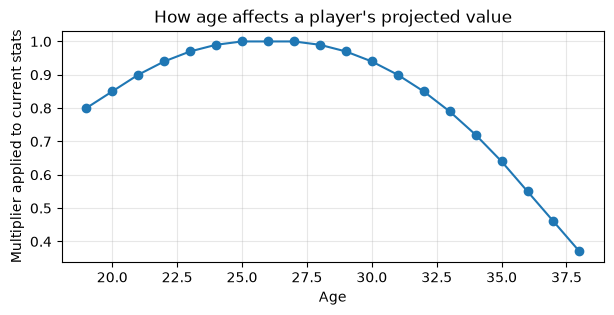

Jaylen Brown         value score = 70.5
Kristaps Porzingis   value score = 62.6
D'Angelo Russell     value score = 48.3
Gabe Vincent         value score = 25.9


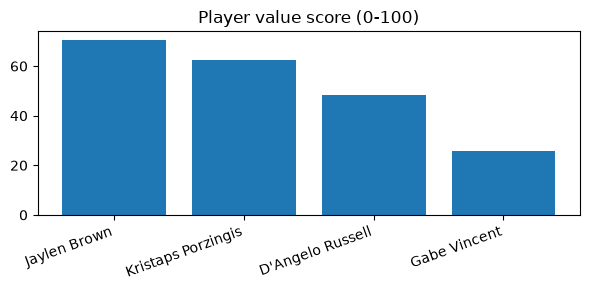

Spending level: Over the Second Apron
Allowed? False
 - Teams at the strictest spending level cannot take back more salary than they send out. Incoming $15,000,000 is more than the outgoing $10,000,000.

Suggested fix: DEMO would need to send out roughly $5,000,000 more in salary for this trade to be allowed.


# Trade Analysis Report
**Proposed trade:** BOS sends Jrue Holiday to LAL for D'Angelo Russell, Gabe Vincent.

## Boston Celtics (BOS) -- Grade: A
- Spending level: **Under the Salary Cap** (payroll $151,250,500)
- Trade allowed: YES (outgoing $32,400,000, incoming $29,492,000, max allowed $35,796,500)
- Value analysis: acquired 74.2, gave up 32.5, **net +41.7**
- Roster before trade: average age 30.4, positions {'SG': 1, 'PG': 2, 'C': 1, 'SF': 1}

## Los Angeles Lakers (LAL) -- Grade: D
- Spending level: **Under the Salary Cap** (payroll $113,919,000)
- Trade allowed: YES (outgoing $29,492,000, incoming $32,400,000, max allowed $70,220,000)
- Value analysis: acquired 32.5, gave up 74.2, **net -41.7**
- Roster before trade: average age 28.8, positions {'PF': 2, 'PG': 2, 'SG': 1}


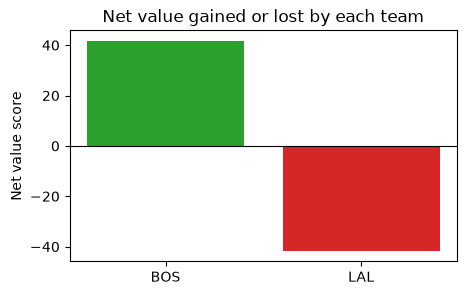

# Trade Analysis Report
**Proposed trade:** BOS sends Jaylen Brown, Sam Hauser to LAL for D'Angelo Russell.

## Boston Celtics (BOS) -- Grade: F (Not Allowed)
- Spending level: **Over the Second Apron** (payroll $242,000,800)
- Trade allowed: NO (outgoing $94,729,280, incoming $18,692,000, max allowed $94,729,280)
  - Problem: Teams at the strictest spending level cannot combine several outgoing players' salaries into one trade.
- Value analysis: acquired 48.3, gave up 107.4, **net -59.1**
- Roster before trade: average age 30.4, positions {'SG': 1, 'PG': 2, 'C': 1, 'SF': 1}

## Los Angeles Lakers (LAL) -- Grade: F (Not Allowed)
- Spending level: **Under the Salary Cap** (payroll $113,919,000)
- Trade allowed: NO (outgoing $18,692,000, incoming $94,729,280, max allowed $59,420,000)
  - Problem: Incoming salary $94,729,280 is more than the team's remaining room ($40,728,000) plus the outgoing salary ($18,692,000).
  - Suggested fix: LAL would need to send out roughly $35,309,280 more in salary for this trade to be allowed.
- Value analysis: acquired 107.4, gave up 48.3, **net +59.1**
- Roster before trade: average age 28.8, positions {'PF': 2, 'PG': 2, 'SG': 1}


In [1]:
import os

# Load any GEMINI_API_KEY / ANTHROPIC_API_KEY saved in a .env file at the
# project root, if one exists, so you don't have to export it manually every
# time. If python-dotenv isn't installed, this is skipped quietly -- you can
# still set the variable yourself before starting Jupyter.
try:
    from dotenv import load_dotenv
    load_dotenv(dotenv_path="../.env")
except ImportError:
    pass

# %run executes another notebook as if you had typed and run every one of its
# cells right here. Afterward, everything notebook 1 defined -- TEAMS,
# run_trade_analysis, render_markdown_report, and so on -- is available below.
%run "01_trade_analyzer_core.ipynb"


## Step 2: Give the AI agents a trustworthy tool to call

This "tool" is a thin wrapper: it calls `run_trade_analysis` and
`render_markdown_report`, both defined in notebook 1, and returns the result
as text the agents can read. All of the actual math still happens in
notebook 1's plain code -- the agents only read the result.

In [2]:
HAVE_CREWAI = False
try:
    # crewai is the library that manages the AI agents, and its "tool"
    # decorator is how we let an agent call a Python function.
    from crewai import Agent, Crew, Process, Task
    from crewai.tools import tool
    HAVE_CREWAI = True
except ImportError:
    print("crewai is not installed. Run `pip install crewai` to enable this notebook fully.")

if HAVE_CREWAI:
    @tool("Run Full Trade Analysis")   # this name is what the AI agents will see and call
    def run_full_trade_analysis_tool(trade_json: str) -> str:
        # The text below becomes the tool's built-in instructions for the AI
        # agents, explaining what it does and what input it expects.
        "Runs the full trade analysis for a proposed trade and returns a JSON summary plus a report. trade_json is a JSON string with keys team_a, team_b, team_a_sends, team_b_sends (lists of player names)."
        import json as _json
        trade = _json.loads(trade_json)          # turn the agent's text input into a Python dict
        result = run_trade_analysis(trade)        # reuse notebook 1's pipeline -- no re-implementing math here
        report = render_markdown_report(result)
        # Build a compact summary too, since it's easier for the AI model to
        # read a few key facts than to re-parse the whole report every time.
        summary = {
            team: {
                "grade": data["grade"],
                "spending_level": data["legality"].cap_status.value,
                "allowed": data["legality"].legal,
                "problems": data["legality"].violations,
                "net_value_score": data["impact"]["net_value_score"],
            }
            for team, data in result["teams"].items()
        }
        # Tools must return plain text, so we convert our result back to a JSON string.
        return _json.dumps({"summary": summary, "report": report}, indent=2)

    print("Tool ready:", run_full_trade_analysis_tool.name)


crewai is not installed. Run `pip install crewai` to enable this notebook fully.


## Step 3: Define the four AI agents and what each one should do

By default this uses Gemini 2.5 Flash (a solid, widely available free-tier
model) when a `GEMINI_API_KEY` is set. If Google has released a newer Gemini
model since this notebook was written, point at it instead by setting the
`TRADE_ANALYZER_MODEL` environment variable, for example:
`export TRADE_ANALYZER_MODEL=gemini/gemini-3.7-flash`.

In [3]:
def _pick_model_and_key():
    # Prefer a free Gemini key (Google AI Studio) if one is set; fall back to
    # Anthropic if that's what the user has instead. TRADE_ANALYZER_MODEL
    # always wins if explicitly set, in case you want to force a specific model.
    if os.environ.get("TRADE_ANALYZER_MODEL"):
        return os.environ["TRADE_ANALYZER_MODEL"], True
    if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
        return "gemini/gemini-2.5-flash", True
    if os.environ.get("ANTHROPIC_API_KEY"):
        return "anthropic/claude-sonnet-4-5-20250929", True
    return None, False   # no usable key found anywhere


MODEL, HAVE_KEY = _pick_model_and_key()

def build_crew(trade):
    # Builds the whole "crew": four AI agents, each given a role, a goal, and
    # a short personality (backstory) that shapes how it responds, plus the
    # ordered list of tasks they'll work through one after another.
    import json as _json
    trade_json = _json.dumps(trade)   # agents receive plain text, so we serialize the trade to JSON

    data_scout = Agent(
        role="Data Scout",
        goal="Find and summarize accurate roster, salary, and performance data.",
        backstory="A careful researcher who trusts verified data over assumptions.",
        llm=MODEL, verbose=True,   # verbose=True prints the agent's reasoning steps as it works
    )
    analyst = Agent(
        role="Analyst",
        goal="Explain what the trade means for each team's on-court performance.",
        backstory="A data-driven analyst who focuses on player value and team fit.",
        llm=MODEL, verbose=True,
    )
    cap_specialist = Agent(
        role="Cap Specialist",
        goal="Check whether the trade follows the salary-cap rules and suggest fixes if not.",
        backstory="Knows the league's spending rules well and always explains problems clearly.",
        llm=MODEL, verbose=True,
    )
    gm_agent = Agent(
        role="General Manager",
        goal="Combine everyone's findings into one final graded recommendation.",
        backstory="An experienced decision-maker who balances short-term and long-term value.",
        llm=MODEL, verbose=True,
    )

    # Each Task tells one agent what to do and which tool(s) it's allowed to
    # use. "context=[scout_task]" means this task gets to see the previous
    # task's output before it starts -- that's how the agents "collaborate"
    # instead of working in isolation.
    scout_task = Task(
        description=f"Using the trade analysis tool with trade_json={trade_json!r}, summarize each "
                     "team's spending level and the players changing hands. Facts only.",
        expected_output="A short factual summary for both teams.",
        agent=data_scout, tools=[run_full_trade_analysis_tool],
    )
    analyst_task = Task(
        description="Using the same tool output, explain the net value score for each team in plain "
                     "language and what it means for their on-court performance.",
        expected_output="A short, plain-language value analysis for each team.",
        agent=analyst, tools=[run_full_trade_analysis_tool], context=[scout_task],
    )
    cap_task = Task(
        description="Using the same tool output, state clearly whether the trade is allowed for each "
                     "team, explaining any problems and the suggested fix in plain language.",
        expected_output="An allowed/not-allowed verdict with a plain-language reason for each team.",
        agent=cap_specialist, tools=[run_full_trade_analysis_tool], context=[scout_task],
    )
    gm_task = Task(
        # The GM sees all three previous tasks' output but has no tool of its
        # own -- its job is purely to summarize what the others already found.
        description="Combine the scouting, value, and rules findings into one final report: a letter "
                     "grade per team (matching the tool's grade), a short explanation per team, and "
                     "one sentence on whether this trade is realistic.",
        expected_output="A final plain-language recommendation with letter grades for both teams.",
        agent=gm_agent, context=[scout_task, analyst_task, cap_task],
    )

    # Process.sequential means the tasks run one after another, in the order
    # listed, each one able to see the results of the tasks before it.
    return Crew(
        agents=[data_scout, analyst, cap_specialist, gm_agent],
        tasks=[scout_task, analyst_task, cap_task, gm_task],
        process=Process.sequential, verbose=True,
    )

print("build_crew() defined.")


build_crew() defined.

## Step 4: Run the agents, or see what would happen without a key

In [4]:
# The same trade we analyzed in notebook 1, so you can compare the AI
# write-up below against that plain report directly.
demo_trade = {
    "team_a": "BOS",
    "team_b": "LAL",
    "team_a_sends": ["Jrue Holiday"],
    "team_b_sends": ["D'Angelo Russell", "Gabe Vincent"],
}

if not HAVE_CREWAI:
    print("Skipping: install crewai first (`pip install crewai`).")
elif not HAVE_KEY:
    print(
        "Skipping: no API key found. Set GEMINI_API_KEY (free, from Google AI "
        "Studio: https://aistudio.google.com/apikey) or ANTHROPIC_API_KEY to let "
        "the four agents reason with a real AI model.\n\n"
        "Here is what would happen if you did:\n"
        "  1. The Data Scout calls the tool and reports each team's spending level and players.\n"
        "  2. The Analyst reads that same result and explains the value trade-off in plain language.\n"
        "  3. The Cap Specialist reads it too and states whether the trade is allowed, with reasons.\n"
        "  4. The General Manager combines all three into a final graded write-up.\n\n"
        "Compare that write-up to the plain report from notebook 1: same grades and numbers, "
        "just explained in fuller sentences."
    )
else:
    # kickoff() actually runs the crew: each agent calls the AI model, uses
    # its tool if needed, and passes its result to the next task in line.
    # This can take anywhere from a few seconds to a minute or so.
    crew = build_crew(demo_trade)
    narrative = crew.kickoff()
    display(Markdown(str(narrative)))


Skipping: install crewai first (`pip install crewai`).


## Notes for teaching

- The **grades and the allowed/not-allowed verdict never change** between
  notebook 1 and this AI-powered run. The AI model only adds explanation on
  top of numbers that were already calculated once, deterministically. That
  is the main idea behind this project: use an AI model for judgment and
  language, not for arithmetic.
- Ideas for extending this project:
  - Add a second General Manager agent for the other team so the two can
    negotiate back and forth automatically.
  - Add an agent that reads fan reaction to a rumored trade from social
    media.
  - Replace the sample data file with a live sports data service.